# 02 – Preprocessing (czyszczenie i inżynieria cech)
**Cel:** Usunięcie wartości odstających, obsługa braków, kodowanie zmiennych kategorycznych, inżynieria cech, zapis przetworzonego datasetu do `data/processed/`.

## 1. Import i wczytanie danych

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
from pathlib import Path
import os
PROJECT_ROOT = Path(os.getcwd())
# Jeśli CWD to notebooks/, cofnij się poziom wyżej
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_PATH    = str(PROJECT_ROOT / 'data' / 'raw' / 'Car_Prices_Poland_Kaggle.csv')
PROC_PATH    = str(PROJECT_ROOT / 'data' / 'processed') + os.sep
FIGURES_PATH = str(PROJECT_ROOT / 'reports' / 'figures') + os.sep
os.makedirs(PROC_PATH, exist_ok=True)
os.makedirs(FIGURES_PATH, exist_ok=True)
print('PROJECT_ROOT:', PROJECT_ROOT)
print('FIGURES_PATH:', FIGURES_PATH)

PROJECT_ROOT: C:\Uni\Projekt_DB_KB_PA
FIGURES_PATH: C:\Uni\Projekt_DB_KB_PA\reports\figures\


In [2]:
df = pd.read_csv(DATA_PATH, index_col=0)
print(f'Wczytano: {df.shape[0]} wierszy, {df.shape[1]} kolumn')
df.head()

Wczytano: 117927 wierszy, 10 kolumn


,mark,model,generation_name,year,mileage,vol_engine,fuel,city,province,price
0,opel,combo,gen-d-2011,2015,139568,1248,Diesel,Janki,Mazowieckie,35900
1,opel,combo,gen-d-2011,2018,31991,1499,Diesel,Katowice,Śląskie,78501
2,opel,combo,gen-d-2011,2015,278437,1598,Diesel,Brzeg,Opolskie,27000
3,opel,combo,gen-d-2011,2016,47600,1248,Diesel,Korfantów,Opolskie,30800
4,opel,combo,gen-d-2011,2014,103000,1400,CNG,Tarnowskie Góry,Śląskie,35900


## 2. Czyszczenie danych

In [3]:
key_cols = ['year', 'mileage', 'vol_engine', 'fuel', 'mark', 'price']
df_clean = df.dropna(subset=key_cols).copy()
print(f'Po usunięciu braków: {df_clean.shape[0]} wierszy')

Po usunięciu braków: 117927 wierszy


In [4]:
print('Przed filtrowaniem:')
print(df_clean[['year','mileage','vol_engine','price']].describe())
df_clean = df_clean[
    (df_clean['price'] > 500) & (df_clean['price'] < 1_500_000) &
    (df_clean['mileage'] >= 0) & (df_clean['mileage'] < 1_500_000) &
    (df_clean['year'] >= 1990) & (df_clean['year'] <= 2022) &
    (df_clean['vol_engine'] >= 0) & (df_clean['vol_engine'] < 10_000)
]
print(f'\nPo filtrowaniu: {df_clean.shape[0]} wierszy')

Przed filtrowaniem:
                year       mileage     vol_engine         price
count  117927.000000  1.179270e+05  117927.000000  1.179270e+05
mean     2012.925259  1.409768e+05    1812.057782  7.029988e+04
std         5.690135  9.236936e+04     643.613438  8.482458e+04
min      1945.000000  0.000000e+00       0.000000  5.000000e+02
25%      2009.000000  6.700000e+04    1461.000000  2.100000e+04
50%      2013.000000  1.462690e+05    1796.000000  4.190000e+04
75%      2018.000000  2.030000e+05    1995.000000  8.360000e+04
max      2022.000000  2.800000e+06    7600.000000  2.399900e+06

Po filtrowaniu: 117849 wierszy


In [5]:
n_before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f'Usunięto duplikatów: {n_before - len(df_clean)}')
print(f'Finalny rozmiar: {df_clean.shape}')

Usunięto duplikatów: 6473
Finalny rozmiar: (111376, 10)


## 3. Normalizacja zmiennych kategorycznych

In [6]:
for col in ['mark', 'model', 'fuel', 'city', 'province', 'generation_name']:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].str.strip().str.lower()
print('Rodzaje paliwa po normalizacji:')
print(df_clean['fuel'].value_counts())

Rodzaje paliwa po normalizacji:
fuel
gasoline    58169
diesel      46029
lpg          4103
hybrid       2280
electric      753
cng            42
Name: count, dtype: int64


## 4. Inżynieria cech

In [7]:
CURRENT_YEAR = 2022
df_clean['car_age'] = CURRENT_YEAR - df_clean['year']
df_clean['mileage_per_year'] = df_clean['mileage'] / (df_clean['car_age'].clip(lower=1))
df_clean['log_price'] = np.log1p(df_clean['price'])
df_clean['is_electric_hybrid'] = df_clean['fuel'].isin(['electric', 'hybrid']).astype(int)
print(df_clean[['car_age', 'mileage_per_year', 'log_price', 'is_electric_hybrid']].describe())

             car_age  mileage_per_year      log_price  is_electric_hybrid
count  111376.000000     111376.000000  111376.000000       111376.000000
mean        9.097175      15369.732244      10.662151            0.027232
std         5.565461       9835.015327       0.967141            0.162760
min         0.000000          0.000000       6.803505            0.000000
25%         5.000000      10000.000000       9.961804            0.000000
50%         9.000000      14483.728070      10.633473            0.000000
75%        13.000000      19892.572917      11.302217            0.000000
max        32.000000    1000000.000000      14.129110            1.000000


## 5. Kodowanie zmiennych kategorycznych

In [8]:
mark_median = df_clean.groupby('mark')['price'].median()
df_clean['mark_median_price'] = df_clean['mark'].map(mark_median)
fuel_dummies = pd.get_dummies(df_clean['fuel'], prefix='fuel', drop_first=True)
df_clean = pd.concat([df_clean, fuel_dummies], axis=1)
print(f'Kolumny po kodowaniu: {df_clean.shape[1]}')
df_clean.head(3)

Kolumny po kodowaniu: 20


,mark,model,generation_name,year,mileage,vol_engine,fuel,city,province,price,car_age,mileage_per_year,log_price,is_electric_hybrid,mark_median_price,fuel_diesel,fuel_electric,fuel_gasoline,fuel_hybrid,fuel_lpg
0,opel,combo,gen-d-2011,2015,139568,1248,diesel,janki,mazowieckie,35900,7,19938.285714,10.488520,0,28800.0,True,False,False,False,False
1,opel,combo,gen-d-2011,2018,31991,1499,diesel,katowice,śląskie,78501,4,7997.750000,11.270879,0,28800.0,True,False,False,False,False
2,opel,combo,gen-d-2011,2015,278437,1598,diesel,brzeg,opolskie,27000,7,39776.714286,10.203629,0,28800.0,True,False,False,False,False


## 6. Wizualizacja po czyszczeniu

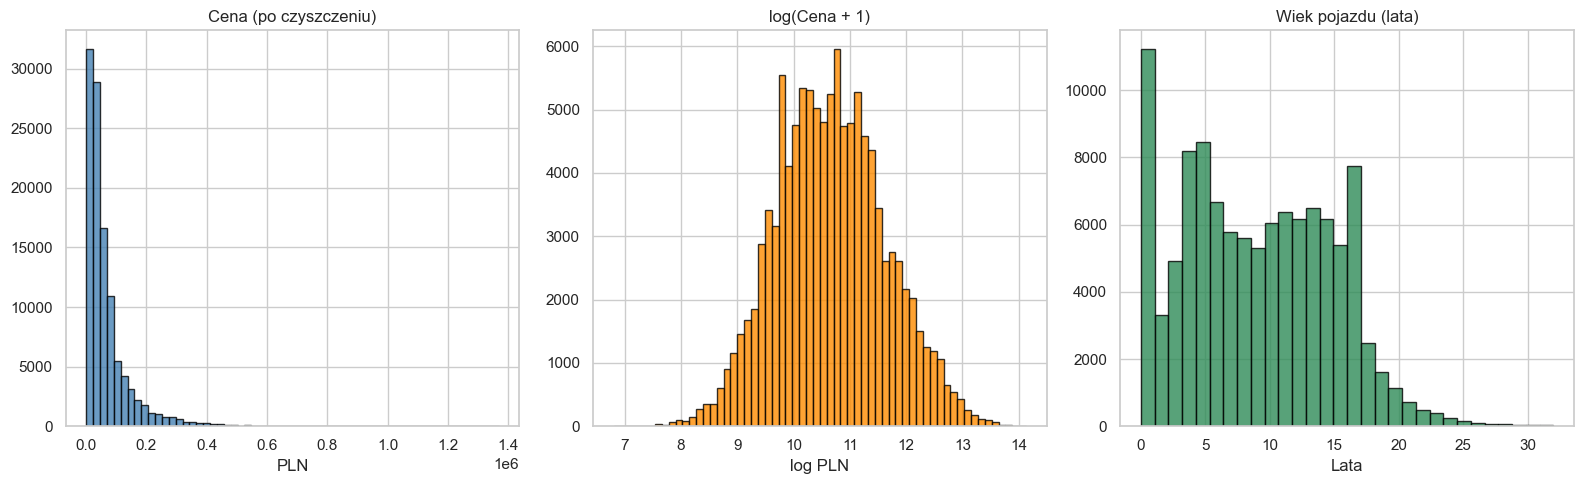

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].hist(df_clean['price'], bins=60, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('Cena (po czyszczeniu)')
axes[0].set_xlabel('PLN')
axes[1].hist(df_clean['log_price'], bins=60, color='darkorange', edgecolor='black', alpha=0.8)
axes[1].set_title('log(Cena + 1)')
axes[1].set_xlabel('log PLN')
axes[2].hist(df_clean['car_age'], bins=30, color='seagreen', edgecolor='black', alpha=0.8)
axes[2].set_title('Wiek pojazdu (lata)')
axes[2].set_xlabel('Lata')
plt.tight_layout()
plt.savefig(FIGURES_PATH + '02_clean_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Zapis przetworzonego datasetu

In [10]:
df_clean.to_csv(PROC_PATH + 'cars_clean.csv', index=False)
print(f'Zapisano: {PROC_PATH}cars_clean.csv  ({df_clean.shape[0]} wierszy, {df_clean.shape[1]} kolumn)')

Zapisano: C:\Uni\Projekt_DB_KB_PA\data\processed\cars_clean.csv  (111376 wierszy, 20 kolumn)
